# Pandas Fundamentals

:::{admonition} Working through this notebook
:class: tip
This page is a Jupyter notebook. **Download it** using the ⬇ button in the top-right (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and step through the cells. When you reach a **Try it** admonition, experiment in your own cells before moving on.
:::

:::{admonition} In-class assignment — 10 points
:class: note
The **"Try it"** exercises in this notebook are part of your in-class assignment for this section. Complete them in your own copy of the notebook, push it to your week folder, and post the notebook link on the matching **Courseworks** assignment. (One 10-point assignment covers all the lecture notebooks in this section.)
:::

Let's start by importing the libraries we'll use throughout this lecture: **pandas** (conventionally imported as `pd`), NumPy, and matplotlib's `pyplot`.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

## Series

Pandas gives you two main objects to work with: a **Series** (one-dimensional, like a single column of labelled data) and a **DataFrame** (two-dimensional, like a table or spreadsheet). DataFrames are built up from Series — each column of a DataFrame is itself a Series — so we'll start with Series and then build up to DataFrame.

A Series is a one-dimensional array of data with an _index_: labels we use to access each value.

There are many ways to [create a Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html). Let's start with a simple example using planet names and masses.

To create a Series, we pass two lists to `pd.Series(...)`: the data **values**, and an `index` containing the **labels** for those values. The output below will show the labels on the left and the values on the right:

In [2]:
names = ['Mercury', 'Venus', 'Earth']
values = [0.3e24, 4.87e24, 5.97e24]
masses = pd.Series(values, index=names)
masses

,0
Mercury,3.000000e+23
Venus,4.870000e+24
Earth,5.970000e+24


Series have built in plotting methods.

<Axes: >

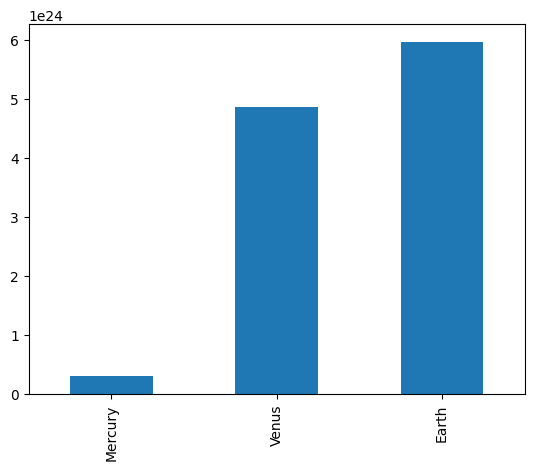

In [3]:
masses.plot(kind='bar')

Arithmetic operations and most numpy function can be applied to Series.
An important point is that the Series keep their index during such operations.

In [4]:
np.log(masses) / masses**2

,0
Mercury,6.006452e-46
Venus,2.396820e-48
Earth,1.600655e-48


We can access the underlying index object if we need to:

In [5]:
masses.index

Index(['Mercury', 'Venus', 'Earth'], dtype='object')

### Indexing

We can get values back out using the index via the `.loc` attribute

In [6]:
masses.loc['Earth']

np.float64(5.97e+24)

Or by raw position using `.iloc`

In [7]:
masses.iloc[2]

np.float64(5.97e+24)

We can pass a list or array to loc to get multiple rows back:

In [8]:
masses.loc[['Venus', 'Earth']]

,0
Venus,4.870000e+24
Earth,5.970000e+24


And we can even use slice notation

In [9]:
masses.loc['Mercury':'Earth']

,0
Mercury,3.000000e+23
Venus,4.870000e+24
Earth,5.970000e+24


In [10]:
masses.iloc[:2]

,0
Mercury,3.000000e+23
Venus,4.870000e+24


If we need to, we can always get the raw data back out as well

In [11]:
masses.values # a numpy array

array([3.00e+23, 4.87e+24, 5.97e+24])

In [12]:
masses.index # a pandas Index object

Index(['Mercury', 'Venus', 'Earth'], dtype='object')

:::{admonition} Try it
:class: tip
In a fresh code cell, build your own `Series` from a Python list of values and a list of labels (any topic of your choice — e.g., capital cities mapped to populations). Use `.loc[]` to access one element by label, and `.iloc[]` to access the same element by position. Then slice with `.loc[]` over a *label* range — note that both the start and end labels are included (unlike Python list slicing).
:::

In [13]:
# Try it — my attempt
caps = pd.Series([8804190, 2161000, 697000], index=['New York', 'Paris', 'Oslo'])
print(caps.loc['Paris'])      # by label
print(caps.iloc[1])           # by position (same element)
caps.loc['New York':'Paris']  # label slice — BOTH endpoints included

2161000
2161000


,0
New York,8804190
Paris,2161000


## DataFrame

There is a lot more to Series, but they are limited to a single "column". A more useful Pandas data structure is the DataFrame. A DataFrame is basically a bunch of series that share the same index. It's a lot like a table in a spreadsheet.

Below we create a DataFrame.

Now let's build a `DataFrame`. The most common pattern is to start with a Python dictionary mapping column names to lists of values, then pass it to `pd.DataFrame`:

In [14]:
data = {'mass': [0.3e24, 4.87e24, 5.97e24],       # kg
        'diameter': [4879e3, 12_104e3, 12_756e3], # m
        'rotation_period': [1407.6, np.nan, 23.9] # h
       }
df = pd.DataFrame(data, index=['Mercury', 'Venus', 'Earth'])
df

,mass,diameter,rotation_period
Mercury,3.000000e+23,4879000.0,1407.6
Venus,4.870000e+24,12104000.0,NaN
Earth,5.970000e+24,12756000.0,23.9


Pandas handles missing data very elegantly, keeping track of it through all calculations.

DataFrames come with a lot of built-in inspection and summary methods. A few of the most useful:

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, Mercury to Earth
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mass             3 non-null      float64
 1   diameter         3 non-null      float64
 2   rotation_period  2 non-null      float64
dtypes: float64(3)
memory usage: 96.0+ bytes


A wide range of statistical functions are available on both Series and DataFrames.

In [16]:
df.min()

,0
mass,3.000000e+23
diameter,4.879000e+06
rotation_period,2.390000e+01


In [17]:
df.mean()

,0
mass,3.713333e+24
diameter,9.913000e+06
rotation_period,7.157500e+02


In [18]:
df.std()

,0
mass,3.006765e+24
diameter,4.371744e+06
rotation_period,9.784237e+02


In [19]:
df.describe()

,mass,diameter,rotation_period
count,3.000000e+00,3.000000e+00,2.000000
mean,3.713333e+24,9.913000e+06,715.750000
std,3.006765e+24,4.371744e+06,978.423653
min,3.000000e+23,4.879000e+06,23.900000
25%,2.585000e+24,8.491500e+06,369.825000
50%,4.870000e+24,1.210400e+07,715.750000
75%,5.420000e+24,1.243000e+07,1061.675000
max,5.970000e+24,1.275600e+07,1407.600000


We can get a single column as a Series using python's getitem syntax on the DataFrame object.

In [20]:
df['mass']

,mass
Mercury,3.000000e+23
Venus,4.870000e+24
Earth,5.970000e+24


...or using attribute syntax.

In [21]:
df.mass

,mass
Mercury,3.000000e+23
Venus,4.870000e+24
Earth,5.970000e+24


:::{admonition} Try it
:class: tip
Build your own `DataFrame` from a dictionary of columns (any topic — e.g. a few cities with `population`, `area`, and `elevation`), passing an `index` of labels. Include at least one `np.nan` so you can see how pandas reports missing data. Inspect its structure with `.info()` and `.describe()`, then compute a few summary statistics with `.mean()`, `.min()`, and `.std()` — try them on the whole DataFrame and on a single column (e.g. `df['population'].mean()`). Finally, pull a column out as a Series using both `df['col']` and `df.col`.
:::

In [22]:
# Try it — my attempt
data = {'population': [8804190, 2161000, np.nan],
        'area': [783.8, 105.4, 454.0],
        'elevation': [10, 35, 23]}
cities = pd.DataFrame(data, index=['New York', 'Paris', 'Oslo'])
cities.info()
display(cities.describe())
print('whole-frame mean:'); print(cities.mean(numeric_only=True))
print('min:', cities['population'].min(), ' std:', round(cities['population'].std(), 1))
print(cities['population'].mean(), cities.population.mean())  # both syntaxes

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, New York to Oslo
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  2 non-null      float64
 1   area        3 non-null      float64
 2   elevation   3 non-null      int64  
dtypes: float64(2), int64(1)
memory usage: 96.0+ bytes


,population,area,elevation
count,2.000000e+00,3.000000,3.000000
mean,5.482595e+06,447.733333,22.666667
std,4.697445e+06,339.243413,12.503333
min,2.161000e+06,105.400000,10.000000
25%,3.821798e+06,279.700000,16.500000
50%,5.482595e+06,454.000000,23.000000
75%,7.143392e+06,618.900000,29.000000
max,8.804190e+06,783.800000,35.000000


whole-frame mean:
population    5.482595e+06
area          4.477333e+02
elevation     2.266667e+01
dtype: float64
min: 2161000.0  std: 4697444.7
5482595.0 5482595.0


Indexing works very similar to series

In [23]:
df.loc['Earth']

,Earth
mass,5.970000e+24
diameter,1.275600e+07
rotation_period,2.390000e+01


In [24]:
df.iloc[2]

,Earth
mass,5.970000e+24
diameter,1.275600e+07
rotation_period,2.390000e+01


But we can also specify the column we want to access

In [25]:
df.loc['Earth', 'mass']

np.float64(5.97e+24)

In [26]:
df.iloc[:2, 0]

,mass
Mercury,3.000000e+23
Venus,4.870000e+24


If we make a calculation using columns from the DataFrame, it will keep the same index:

In [27]:
volume =  4/3 * np.pi * (df.diameter/2)**3
df.mass / volume

,0
Mercury,4933.216530
Venus,5244.977070
Earth,5493.285577


Which we can easily add as another column to the DataFrame:

In [28]:
df['density'] = df.mass / volume
df

,mass,diameter,rotation_period,density
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530
Venus,4.870000e+24,12104000.0,NaN,5244.977070
Earth,5.970000e+24,12756000.0,23.9,5493.285577


## Merging Data

Pandas supports a wide range of methods for merging different datasets. These are described extensively in the [documentation](https://pandas.pydata.org/pandas-docs/stable/merging.html). Here we just give a few examples.

Pandas can merge DataFrames and Series intelligently along their shared index. Let's create a separate `Series` of planet temperatures and combine it with our existing DataFrame:

In [29]:
temperature = pd.Series([167, 464, 15, -65],
                     index=['Mercury', 'Venus', 'Earth', 'Mars'],
                     name='temperature')
temperature

,temperature
Mercury,167
Venus,464
Earth,15
Mars,-65


In [30]:
df.join(temperature)

,mass,diameter,rotation_period,density,temperature
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,167
Venus,4.870000e+24,12104000.0,NaN,5244.977070,464
Earth,5.970000e+24,12756000.0,23.9,5493.285577,15


By default, `join` keeps the calling DataFrame's index — a *left* join — so Mars is dropped, since it isn't one of our three planets. The `how` keyword changes this: `how='right'` keeps the *other* object's index instead, so Mars appears (with `NaN` for the columns we don't have for it):

In [31]:
df.join(temperature, how='right')

,mass,diameter,rotation_period,density,temperature
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,167
Venus,4.870000e+24,12104000.0,NaN,5244.977070,464
Earth,5.970000e+24,12756000.0,23.9,5493.285577,15
Mars,NaN,NaN,NaN,NaN,-65


`reindex` is a more general tool: it conforms a DataFrame to a brand-new index that you supply, inserting rows of `NaN` wherever a label wasn't already present:

In [32]:
everyone = df.reindex(['Mercury', 'Venus', 'Earth', 'Mars'])
everyone

,mass,diameter,rotation_period,density
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530
Venus,4.870000e+24,12104000.0,NaN,5244.977070
Earth,5.970000e+24,12756000.0,23.9,5493.285577
Mars,NaN,NaN,NaN,NaN


:::{admonition} Try it
:class: tip
Create a new `Series` of values indexed by some of the planets — you can include one that isn't in the DataFrame (e.g. Mars or Jupiter) — and `join` it onto the planets DataFrame. Try `how='right'` and compare the result with the default join. Then call `.reindex(...)` with your own list of planet names and notice how pandas fills in `NaN` for labels that weren't present.
:::

In [33]:
# Try it — my attempt
temp = pd.Series([167, 464, 15, -65], index=['Mercury', 'Venus', 'Earth', 'Mars'], name='temp_C')
display(df.join(temp))             # default left join -> Mars dropped
display(df.join(temp, how='right'))  # right join -> Mars appears with NaNs
df.reindex(['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter'])  # NaN rows for new labels

,mass,diameter,rotation_period,density,temp_C
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,167
Venus,4.870000e+24,12104000.0,NaN,5244.977070,464
Earth,5.970000e+24,12756000.0,23.9,5493.285577,15


,mass,diameter,rotation_period,density,temp_C
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,167
Venus,4.870000e+24,12104000.0,NaN,5244.977070,464
Earth,5.970000e+24,12756000.0,23.9,5493.285577,15
Mars,NaN,NaN,NaN,NaN,-65


,mass,diameter,rotation_period,density
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530
Venus,4.870000e+24,12104000.0,NaN,5244.977070
Earth,5.970000e+24,12756000.0,23.9,5493.285577
Mars,NaN,NaN,NaN,NaN
Jupiter,NaN,NaN,NaN,NaN


Another powerful way to select data is to pick rows based on a **condition** rather than by their label or position. A comparison like `df.mass > 4e24` is checked for every row and returns a *boolean Series* — a column of `True`/`False` values, one per planet. Placing that inside `df[...]` keeps only the rows where the value is `True`. For example, to get just the planets more massive than `4e24` kg:

In [34]:
adults = df[df.mass > 4e24]
adults

,mass,diameter,rotation_period,density
Venus,4.870000e+24,12104000.0,NaN,5244.977070
Earth,5.970000e+24,12756000.0,23.9,5493.285577


Since that condition is itself just a Series of `True`/`False` values, we can also store it as a new column — a handy way to flag the rows that meet the criterion:

In [35]:
df['is_big'] = df.mass > 4e24
df

,mass,diameter,rotation_period,density,is_big
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,False
Venus,4.870000e+24,12104000.0,NaN,5244.977070,True
Earth,5.970000e+24,12756000.0,23.9,5493.285577,True


### Modifying Values

We often want to modify values in a dataframe based on some rule. To modify values, we need to use `.loc` or `.iloc`

In [36]:
df.loc['Earth', 'mass'] = 5.98e+24
df.loc['Venus', 'diameter'] += 1
df

,mass,diameter,rotation_period,density,is_big
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,False
Venus,4.870000e+24,12104001.0,NaN,5244.977070,True
Earth,5.980000e+24,12756000.0,23.9,5493.285577,True


:::{admonition} Try it
:class: tip
Take the planets DataFrame from above. Use `.loc[]` to get all of Earth's data, then `.iloc[:3]` to get the first three rows. Add a new column called `density_check` computed as `df.mass / (4/3 * np.pi * (df.diameter/2)**3)`, then filter the DataFrame to planets with mass greater than 1e24.
:::

In [37]:
# Try it — my attempt
display(df.loc['Earth'])
display(df.iloc[:3])
df['density_check'] = df.mass / (4/3 * np.pi * (df.diameter/2)**3)
df[df.mass > 1e24]

,Earth
mass,5980000000000000511705088.0
diameter,12756000.0
rotation_period,23.9
density,5493.285577
is_big,True


,mass,diameter,rotation_period,density,is_big
Mercury,3.000000e+23,4879000.0,1407.6,4933.216530,False
Venus,4.870000e+24,12104001.0,NaN,5244.977070,True
Earth,5.980000e+24,12756000.0,23.9,5493.285577,True


,mass,diameter,rotation_period,density,is_big,density_check
Venus,4.870000e+24,12104001.0,NaN,5244.977070,True,5244.975770
Earth,5.980000e+24,12756000.0,23.9,5493.285577,True,5502.487061


## Plotting

DataFrames have all kinds of [useful plotting](https://pandas.pydata.org/pandas-docs/stable/visualization.html) built in.

<Axes: xlabel='mass', ylabel='diameter'>

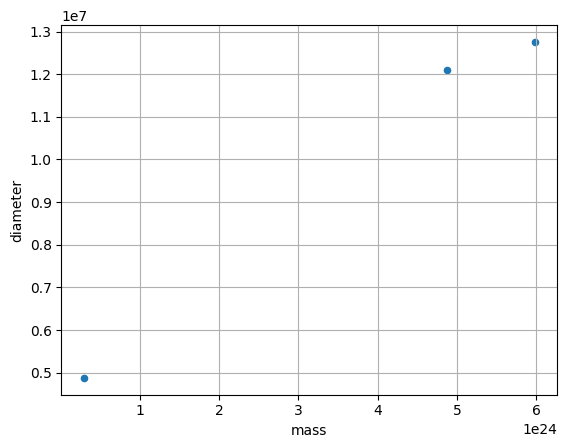

In [38]:
df.plot(kind='scatter', x='mass', y='diameter', grid=True)

<Axes: >

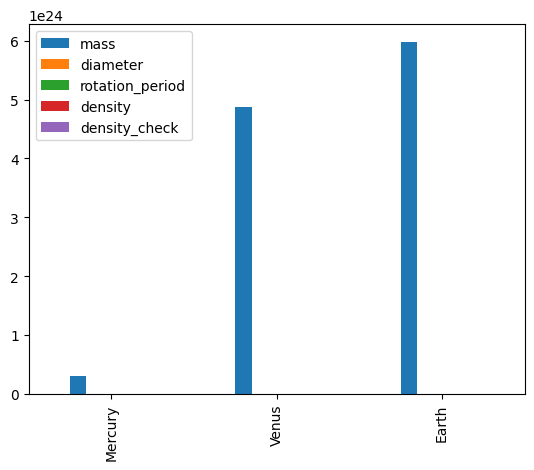

In [39]:
df.plot(kind='bar')

:::{admonition} Try it
:class: tip
Make a scatter plot of `diameter` vs `mass` from the planets DataFrame. Then make a bar chart of each planet's mass. (You can stay with `df.plot(kind='...')`, or use `df.plot.scatter(...)` / `df.plot.bar(...)` — both work.)
:::

<Axes: title={'center': 'Planet mass'}, xlabel='mass', ylabel='diameter'>

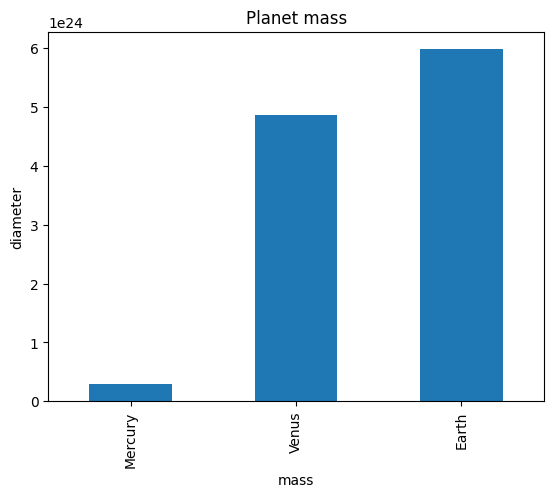

In [40]:
# Try it — my attempt
df.plot(kind='scatter', x='mass', y='diameter', grid=True)
df['mass'].plot(kind='bar', title='Planet mass')

## Time Indexes

Indexes are very powerful. They are a big part of why Pandas is so useful. There are different indices for different types of data. Time Indexes are especially great!

To build a time-indexed Series we first need a sequence of dates. `pd.date_range` generates one for us: we give it a `start` and `end` date and a frequency `freq` (here `'D'` for one timestamp per day), and it returns a `DatetimeIndex` of evenly spaced timestamps. Below we make two years of daily dates, then use them as the index of a `Series` whose values trace a seasonal sine wave — `.dayofyear` counts 1–365 through the year, so one full cycle spans a year:

<Axes: >

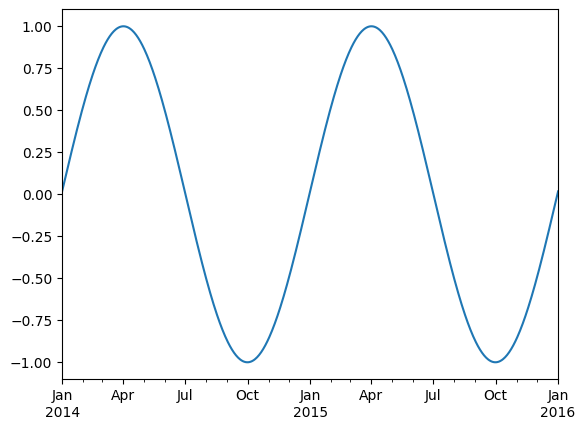

In [41]:
two_years = pd.date_range(start='2014-01-01', end='2016-01-01', freq='D')
timeseries = pd.Series(np.sin(2 *np.pi *two_years.dayofyear / 365),
                       index=two_years)
timeseries.plot()

We can use python's slicing notation inside `.loc` to select a date range.

<Axes: >

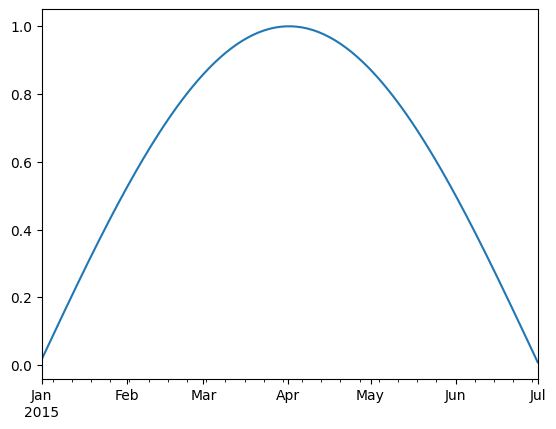

In [42]:
timeseries.loc['2015-01-01':'2015-07-01'].plot()

The TimeIndex object has lots of useful attributes

In [43]:
timeseries.index.month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12,  1],
      dtype='int32', length=731)

In [44]:
timeseries.index.day

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
       23, 24, 25, 26, 27, 28, 29, 30, 31,  1],
      dtype='int32', length=731)

:::{admonition} Try it
:class: tip
Use `pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')` to create a year of daily timestamps. Wrap them in a `Series` whose values are `np.random.randn(len(...))`. Slice it to get just March through May 2023 (use `.loc['2023-03':'2023-05']`), then call `.plot()`.
:::

<Axes: title={'center': 'Mar–May 2023'}>

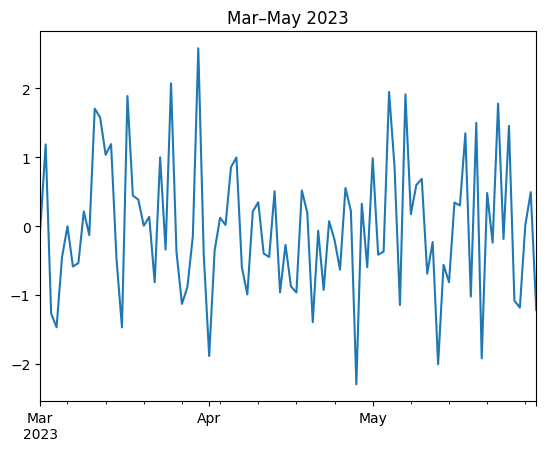

In [45]:
# Try it — my attempt
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
ts = pd.Series(np.random.randn(len(dates)), index=dates)
ts.loc['2023-03':'2023-05'].plot(title='Mar–May 2023')

## Reading Data Files: Weather Station Data

In this example, we will use NOAA weather station data from https://www.ncdc.noaa.gov/data-access/land-based-station-data.

The details of files we are going to read are described in this README file (<ftp://ftp.ncdc.noaa.gov/pub/data/uscrn/products/daily01/README.txt>).

In [46]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    base_url="doi:10.5281/zenodo.5564850/",
    registry={
        "data.txt": "md5:5129dcfd19300eb8d4d8d1673fcfbcb4",
    },
)
datafile = POOCH.fetch("data.txt")
datafile

'/root/.cache/noaa-data/data.txt'

In [47]:
! head {datafile}

WBANNO LST_DATE CRX_VN LONGITUDE LATITUDE T_DAILY_MAX T_DAILY_MIN T_DAILY_MEAN T_DAILY_AVG P_DAILY_CALC SOLARAD_DAILY SUR_TEMP_DAILY_TYPE SUR_TEMP_DAILY_MAX SUR_TEMP_DAILY_MIN SUR_TEMP_DAILY_AVG RH_DAILY_MAX RH_DAILY_MIN RH_DAILY_AVG SOIL_MOISTURE_5_DAILY SOIL_MOISTURE_10_DAILY SOIL_MOISTURE_20_DAILY SOIL_MOISTURE_50_DAILY SOIL_MOISTURE_100_DAILY SOIL_TEMP_5_DAILY SOIL_TEMP_10_DAILY SOIL_TEMP_20_DAILY SOIL_TEMP_50_DAILY SOIL_TEMP_100_DAILY 
64756 20170101  2.422  -73.74   41.79     6.6    -5.4     0.6     2.2     0.0     8.68 C     7.9    -6.6    -0.5    84.8    30.7    53.7 -99.000 -99.000   0.207   0.152   0.175    -0.1     0.0     0.6     1.5     3.4
64756 20170102  2.422  -73.74   41.79     4.0    -6.8    -1.4    -1.2     0.0     2.08 C     4.1    -7.1    -1.6    91.1    49.1    77.4 -99.000 -99.000   0.205   0.151   0.173    -0.2     0.0     0.6     1.5     3.3
64756 20170103  2.422  -73.74   41.79     4.9     0.7     2.8     2.7    13.1     0.68 C     3.9     0.1     1.6    96.5 

We now have a text file on our hard drive called `data.txt`. Examine it.

To read it into pandas, we will use the [read_csv](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) function. This function is incredibly complex and powerful. You can use it to extract data from almost any text file. However, you need to understand how to use its various options.

With no options, this is what we get.

In [48]:
df = pd.read_csv(datafile)
df.head()

,WBANNO LST_DATE CRX_VN LONGITUDE LATITUDE T_DAILY_MAX T_DAILY_MIN T_DAILY_MEAN T_DAILY_AVG P_DAILY_CALC SOLARAD_DAILY SUR_TEMP_DAILY_TYPE SUR_TEMP_DAILY_MAX SUR_TEMP_DAILY_MIN SUR_TEMP_DAILY_AVG RH_DAILY_MAX RH_DAILY_MIN RH_DAILY_AVG SOIL_MOISTURE_5_DAILY SOIL_MOISTURE_10_DAILY SOIL_MOISTURE_20_DAILY SOIL_MOISTURE_50_DAILY SOIL_MOISTURE_100_DAILY SOIL_TEMP_5_DAILY SOIL_TEMP_10_DAILY SOIL_TEMP_20_DAILY SOIL_TEMP_50_DAILY SOIL_TEMP_100_DAILY
0,64756 20170101 2.422 -73.74 41.79 6.6 ...
1,64756 20170102 2.422 -73.74 41.79 4.0 ...
2,64756 20170103 2.422 -73.74 41.79 4.9 ...
3,64756 20170104 2.422 -73.74 41.79 8.7 ...
4,64756 20170105 2.422 -73.74 41.79 -0.5 ...


Pandas failed to identify the different columns. This is because it expected a standard CSV (comma-separated values) file, but in our file the values are separated by whitespace instead — and not by a single space: the amount of whitespace between columns varies. We tell pandas how the columns are separated with the `sep` keyword.

The value `r'\s+'` is a small *regular expression* — a pattern for matching text. Here `\s` stands for any whitespace character (a space or a tab) and `+` means "one or more in a row," so together they match any run of whitespace, however wide. The leading `r` makes it a *raw string*, which tells Python to leave the backslash alone instead of treating it as a special character.

In [49]:
df = pd.read_csv(datafile, sep=r'\s+')
df.head()

,WBANNO,LST_DATE,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
0,64756,20170101,2.422,-73.74,41.79,6.6,-5.4,0.6,2.2,0.0,...,-99.0,-99.0,0.207,0.152,0.175,-0.1,0.0,0.6,1.5,3.4
1,64756,20170102,2.422,-73.74,41.79,4.0,-6.8,-1.4,-1.2,0.0,...,-99.0,-99.0,0.205,0.151,0.173,-0.2,0.0,0.6,1.5,3.3
2,64756,20170103,2.422,-73.74,41.79,4.9,0.7,2.8,2.7,13.1,...,-99.0,-99.0,0.205,0.150,0.173,-0.1,0.0,0.5,1.5,3.3
3,64756,20170104,2.422,-73.74,41.79,8.7,-1.6,3.6,3.5,1.3,...,-99.0,-99.0,0.215,0.153,0.174,-0.1,0.0,0.5,1.5,3.2
4,64756,20170105,2.422,-73.74,41.79,-0.5,-4.6,-2.5,-2.8,0.0,...,-99.0,-99.0,0.215,0.154,0.177,-0.1,0.0,0.5,1.4,3.1


Great! It worked. 

If we look closely, we will see there are lots of -99 and -9999 values in the file. The README file (<ftp://ftp.ncdc.noaa.gov/pub/data/uscrn/products/daily01/README.txt>) tells us that these are values used to represent missing data. Let's tell this to pandas.

In [50]:
df = pd.read_csv(datafile, sep=r'\s+', na_values=[-9999.0, -99.0])
df.head()

,WBANNO,LST_DATE,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
0,64756,20170101,2.422,-73.74,41.79,6.6,-5.4,0.6,2.2,0.0,...,NaN,NaN,0.207,0.152,0.175,-0.1,0.0,0.6,1.5,3.4
1,64756,20170102,2.422,-73.74,41.79,4.0,-6.8,-1.4,-1.2,0.0,...,NaN,NaN,0.205,0.151,0.173,-0.2,0.0,0.6,1.5,3.3
2,64756,20170103,2.422,-73.74,41.79,4.9,0.7,2.8,2.7,13.1,...,NaN,NaN,0.205,0.150,0.173,-0.1,0.0,0.5,1.5,3.3
3,64756,20170104,2.422,-73.74,41.79,8.7,-1.6,3.6,3.5,1.3,...,NaN,NaN,0.215,0.153,0.174,-0.1,0.0,0.5,1.5,3.2
4,64756,20170105,2.422,-73.74,41.79,-0.5,-4.6,-2.5,-2.8,0.0,...,NaN,NaN,0.215,0.154,0.177,-0.1,0.0,0.5,1.4,3.1


Great. The missing data is now represented by `NaN`.

What data types did pandas infer?

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   WBANNO                   365 non-null    int64  
 1   LST_DATE                 365 non-null    int64  
 2   CRX_VN                   365 non-null    float64
 3   LONGITUDE                365 non-null    float64
 4   LATITUDE                 365 non-null    float64
 5   T_DAILY_MAX              364 non-null    float64
 6   T_DAILY_MIN              364 non-null    float64
 7   T_DAILY_MEAN             364 non-null    float64
 8   T_DAILY_AVG              364 non-null    float64
 9   P_DAILY_CALC             364 non-null    float64
 10  SOLARAD_DAILY            364 non-null    float64
 11  SUR_TEMP_DAILY_TYPE      365 non-null    object 
 12  SUR_TEMP_DAILY_MAX       364 non-null    float64
 13  SUR_TEMP_DAILY_MIN       364 non-null    float64
 14  SUR_TEMP_DAILY_AVG       3

One problem here is that pandas did not recognize the `LST_DATE` column as a date. Let's help it.

In [52]:
df = pd.read_csv(datafile, sep=r'\s+',
                 na_values=[-9999.0, -99.0],
                 parse_dates=[1])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   WBANNO                   365 non-null    int64         
 1   LST_DATE                 365 non-null    datetime64[ns]
 2   CRX_VN                   365 non-null    float64       
 3   LONGITUDE                365 non-null    float64       
 4   LATITUDE                 365 non-null    float64       
 5   T_DAILY_MAX              364 non-null    float64       
 6   T_DAILY_MIN              364 non-null    float64       
 7   T_DAILY_MEAN             364 non-null    float64       
 8   T_DAILY_AVG              364 non-null    float64       
 9   P_DAILY_CALC             364 non-null    float64       
 10  SOLARAD_DAILY            364 non-null    float64       
 11  SUR_TEMP_DAILY_TYPE      365 non-null    object        
 12  SUR_TEMP_DAILY_MAX       364 non-nul

It worked! Finally, let's tell pandas to use the date column as the index.

In [53]:
df = df.set_index('LST_DATE')
df.head()

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2017-01-01,64756,2.422,-73.74,41.79,6.6,-5.4,0.6,2.2,0.0,8.68,...,NaN,NaN,0.207,0.152,0.175,-0.1,0.0,0.6,1.5,3.4
2017-01-02,64756,2.422,-73.74,41.79,4.0,-6.8,-1.4,-1.2,0.0,2.08,...,NaN,NaN,0.205,0.151,0.173,-0.2,0.0,0.6,1.5,3.3
2017-01-03,64756,2.422,-73.74,41.79,4.9,0.7,2.8,2.7,13.1,0.68,...,NaN,NaN,0.205,0.150,0.173,-0.1,0.0,0.5,1.5,3.3
2017-01-04,64756,2.422,-73.74,41.79,8.7,-1.6,3.6,3.5,1.3,2.85,...,NaN,NaN,0.215,0.153,0.174,-0.1,0.0,0.5,1.5,3.2
2017-01-05,64756,2.422,-73.74,41.79,-0.5,-4.6,-2.5,-2.8,0.0,4.90,...,NaN,NaN,0.215,0.154,0.177,-0.1,0.0,0.5,1.4,3.1


We can now access values by time:

In [54]:
df.loc['2017-08-07']

,2017-08-07
WBANNO,64756
CRX_VN,2.422
LONGITUDE,-73.74
LATITUDE,41.79
T_DAILY_MAX,19.3
T_DAILY_MIN,12.3
T_DAILY_MEAN,15.8
T_DAILY_AVG,16.3
P_DAILY_CALC,4.9
SOLARAD_DAILY,3.93


Or use slicing to get a range:

In [55]:
df.loc['2017-07-01':'2017-07-31']

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2017-07-01,64756,2.422,-73.74,41.79,28.0,19.7,23.9,23.8,0.2,19.28,...,0.157,0.136,0.144,0.129,0.163,25.7,25.4,23.7,21.9,19.9
2017-07-02,64756,2.422,-73.74,41.79,29.8,18.4,24.1,23.7,4.0,27.67,...,0.146,0.135,0.143,0.129,0.162,26.8,26.4,24.5,22.3,20.1
2017-07-03,64756,2.422,-73.74,41.79,28.3,15.0,21.7,21.4,0.0,27.08,...,0.141,0.132,0.139,0.128,0.162,26.4,26.3,24.8,22.8,20.3
2017-07-04,64756,2.422,-73.74,41.79,26.8,12.6,19.7,20.0,0.0,29.45,...,0.131,0.126,0.136,0.126,0.161,25.9,25.8,24.6,22.9,20.6
2017-07-05,64756,2.422,-73.74,41.79,28.0,11.9,20.0,20.7,0.0,26.90,...,0.116,0.114,0.131,0.125,0.161,25.3,25.3,24.2,22.8,20.7
2017-07-06,64756,2.422,-73.74,41.79,25.7,14.3,20.0,20.3,0.0,19.03,...,0.105,0.104,0.126,0.124,0.160,24.7,24.7,23.9,22.7,20.9
2017-07-07,64756,2.422,-73.74,41.79,25.8,16.8,21.3,20.0,11.5,13.88,...,0.114,0.100,0.123,0.123,0.160,24.2,24.2,23.4,22.4,20.8
2017-07-08,64756,2.422,-73.74,41.79,29.0,15.3,22.1,21.5,0.0,21.92,...,0.130,0.106,0.122,0.123,0.159,25.5,25.3,23.9,22.4,20.8
2017-07-09,64756,2.422,-73.74,41.79,26.3,10.9,18.6,19.4,0.0,29.72,...,0.119,0.103,0.119,0.121,0.158,24.8,24.8,23.8,22.5,20.8


### Quick Statistics

`describe()` is a fast way to get a feel for a freshly loaded dataset: in one call it reports the count, mean, standard deviation, minimum, the 25/50/75% percentiles, and maximum for every numeric column. It's a good first sanity check — unrealistic values or columns full of `NaN` often jump out right away.

In [56]:
df.describe()

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
count,365.0,365.000000,3.650000e+02,3.650000e+02,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,317.000000,317.000000,336.000000,364.000000,359.000000,364.000000,364.000000,364.000000,364.000000,364.000000
mean,64756.0,2.470767,-7.374000e+01,4.179000e+01,15.720055,4.037912,9.876374,9.990110,2.797802,13.068187,...,0.189498,0.183991,0.165470,0.140192,0.160630,12.312637,12.320604,12.060165,11.978022,11.915659
std,0.0,0.085997,5.265234e-13,3.842198e-13,10.502087,9.460676,9.727451,9.619168,7.238628,7.953074,...,0.052031,0.054113,0.043989,0.020495,0.016011,9.390034,9.338176,8.767752,8.078346,7.187317
min,64756.0,2.422000,-7.374000e+01,4.179000e+01,-12.300000,-21.800000,-17.000000,-16.700000,0.000000,0.100000,...,0.075000,0.078000,0.087000,0.101000,0.117000,-0.700000,-0.400000,0.200000,0.900000,1.900000
25%,64756.0,2.422000,-7.374000e+01,4.179000e+01,6.900000,-2.775000,2.100000,2.275000,0.000000,6.225000,...,0.152000,0.139000,0.118750,0.118000,0.154000,2.225000,2.000000,2.475000,3.300000,4.100000
50%,64756.0,2.422000,-7.374000e+01,4.179000e+01,17.450000,4.350000,10.850000,11.050000,0.000000,12.865000,...,0.192000,0.198000,0.183000,0.147500,0.165000,13.300000,13.350000,13.100000,12.850000,11.600000
75%,64756.0,2.422000,-7.374000e+01,4.179000e+01,24.850000,11.900000,18.150000,18.450000,1.400000,19.740000,...,0.234000,0.227000,0.203000,0.157000,0.173000,21.025000,21.125000,20.400000,19.800000,19.325000
max,64756.0,2.622000,-7.374000e+01,4.179000e+01,33.400000,20.700000,25.700000,26.700000,65.700000,29.910000,...,0.296000,0.321000,0.235000,0.182000,0.192000,27.600000,27.400000,25.600000,24.100000,22.100000


### Plotting Values

We can now quickly make plots of the data

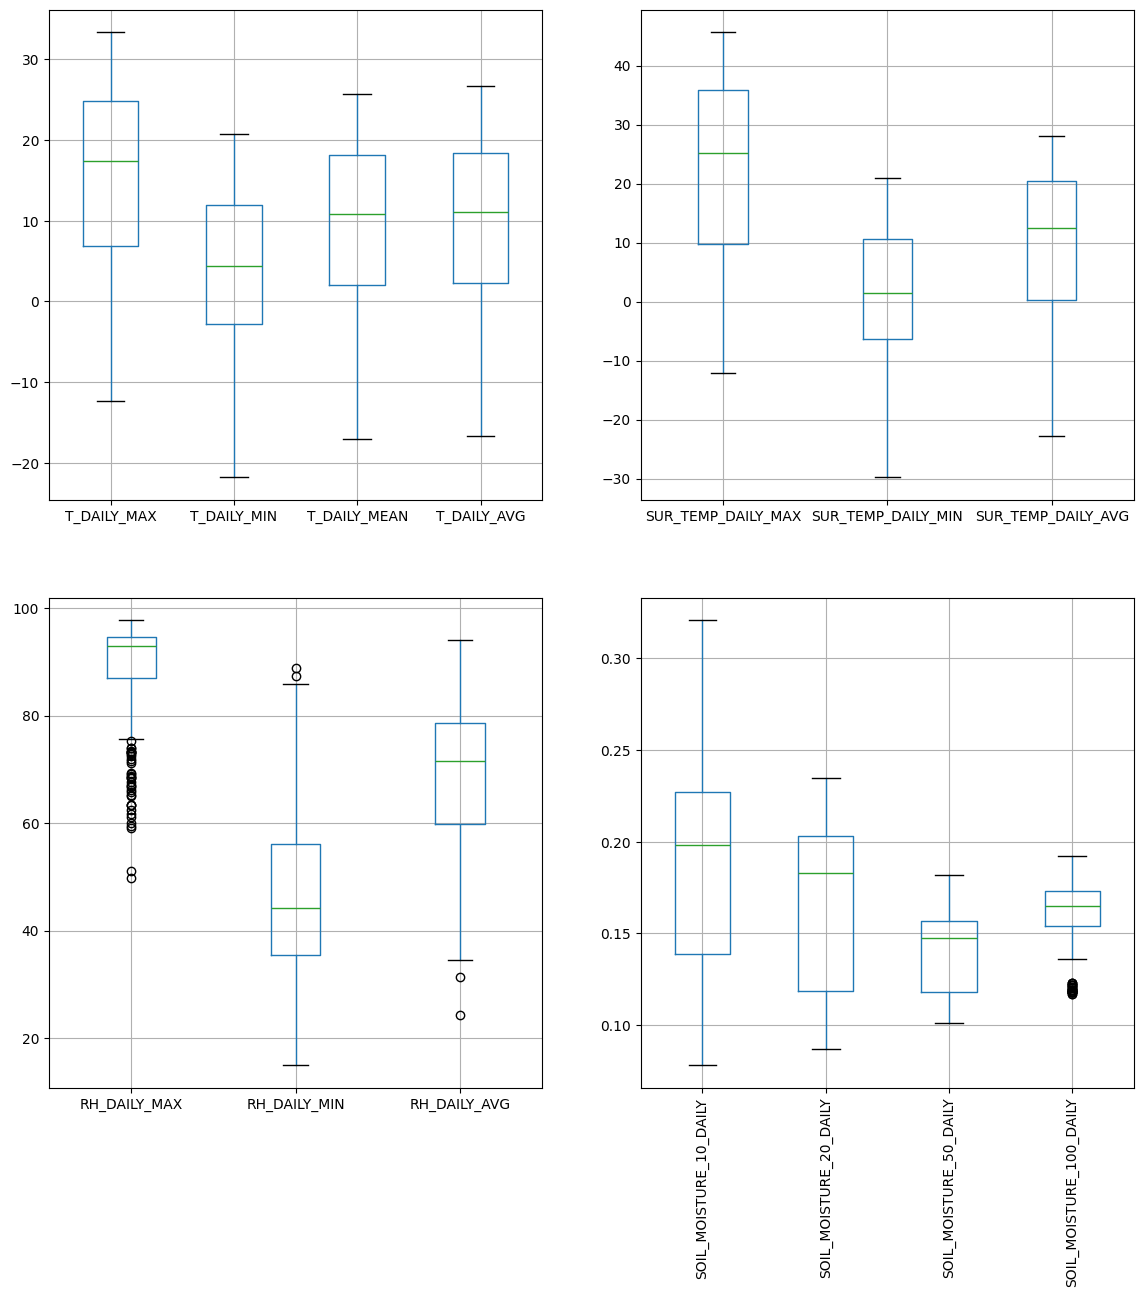

In [57]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(14,14))

df.iloc[:, 4:8].boxplot(ax=ax[0,0])
df.iloc[:, 10:14].boxplot(ax=ax[0,1])
df.iloc[:, 14:17].boxplot(ax=ax[1,0])
df.iloc[:, 18:22].boxplot(ax=ax[1,1])


ax[1, 1].set_xticklabels(ax[1, 1].get_xticklabels(), rotation=90);

Pandas is very "time aware":

<Axes: xlabel='LST_DATE'>

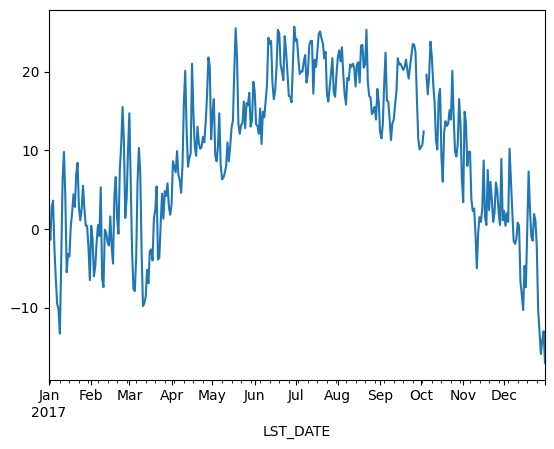

In [58]:
df.T_DAILY_MEAN.plot()

Note: we could also manually create an axis and plot into it.

Text(0.5, 1.0, 'Pandas Made This!')

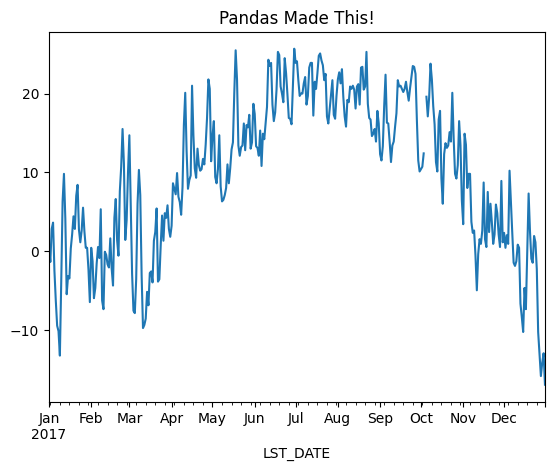

In [59]:
fig, ax = plt.subplots()
df.T_DAILY_MEAN.plot(ax=ax)
ax.set_title('Pandas Made This!')

<Axes: xlabel='LST_DATE'>

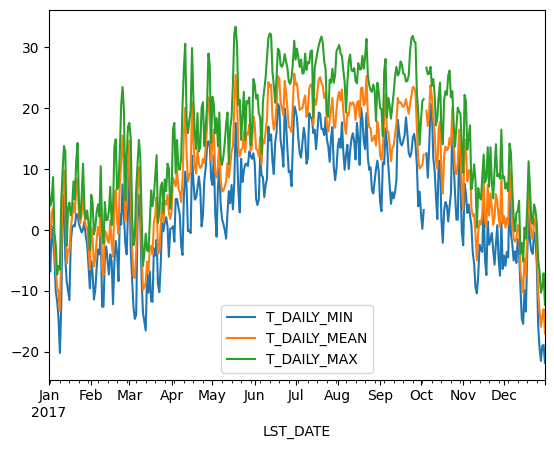

In [60]:
df[['T_DAILY_MIN', 'T_DAILY_MEAN', 'T_DAILY_MAX']].plot()

:::{admonition} Try it
:class: tip
Slice the NOAA `df` to a single month of your choice (e.g., `df.loc['2018-06']`). Call `.describe()` on that subset to get summary stats. Then plot `T_DAILY_MEAN` against the index for that month.
:::

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
count,31.0,3.100000e+01,3.100000e+01,3.100000e+01,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,...,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,64756.0,2.422000e+00,-7.374000e+01,4.179000e+01,26.912903,15.183871,21.048387,20.993548,2.732258,20.566129,...,0.131226,0.115774,0.116613,0.121032,0.156677,24.993548,24.980645,23.925806,22.745161,21.164516
std,0.0,1.805720e-15,2.889152e-14,1.444576e-14,3.329038,3.114707,2.606642,2.359652,6.847013,6.728454,...,0.027255,0.021104,0.012355,0.003610,0.002982,1.514802,1.370503,0.975694,0.654135,0.548664
min,64756.0,2.422000e+00,-7.374000e+01,4.179000e+01,18.500000,8.200000,16.200000,16.200000,0.000000,5.360000,...,0.087000,0.082000,0.099000,0.116000,0.152000,21.900000,22.200000,22.300000,21.900000,19.900000
25%,64756.0,2.422000e+00,-7.374000e+01,4.179000e+01,25.750000,12.950000,19.700000,19.750000,0.000000,17.030000,...,0.109500,0.099500,0.108000,0.118000,0.154500,23.950000,23.950000,23.300000,22.250000,20.850000
50%,64756.0,2.422000e+00,-7.374000e+01,4.179000e+01,27.600000,15.600000,21.500000,21.000000,0.000000,21.280000,...,0.130000,0.114000,0.114000,0.120000,0.156000,25.400000,25.300000,23.900000,22.600000,21.200000
75%,64756.0,2.422000e+00,-7.374000e+01,4.179000e+01,29.300000,17.600000,23.450000,23.000000,0.750000,26.225000,...,0.145500,0.132000,0.123000,0.123000,0.158500,25.900000,25.900000,24.550000,22.950000,21.450000
max,64756.0,2.422000e+00,-7.374000e+01,4.179000e+01,31.800000,19.700000,25.100000,25.000000,29.200000,29.720000,...,0.194000,0.163000,0.144000,0.129000,0.163000,27.600000,27.400000,25.600000,24.100000,22.100000


<Axes: title={'center': 'July 2017 daily mean temperature'}, xlabel='LST_DATE'>

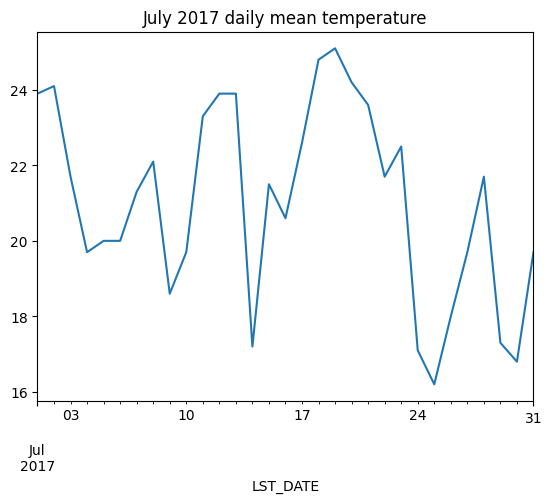

In [61]:
# Try it — my attempt  (uses the NOAA station df loaded above)
june = df.loc['2017-07']
display(june.describe())
june['T_DAILY_MEAN'].plot(title='July 2017 daily mean temperature')

### Resampling

Because pandas understands time, it can **resample** a time series — change how often the data is reported by grouping together all the timestamps that fall in each new time period. Our data is daily, but we might want monthly values; resampling to a monthly frequency gathers all the days in each month so we can summarize them (mean, max, …). It's much like `groupby`, except the groups are consecutive time intervals. The target frequency is given by a short code — below, `'MS'` means "month start" (one value per month); other common codes are `'D'` (daily), `'W'` (weekly), and `'YE'` (year end).

Calling `.resample(...)` returns a *resampler object* — a grouping by time frequency. Apply an aggregation (like `.mean()`) to actually get a smaller DataFrame:

In [62]:
rs_obj = df.select_dtypes(include='number').resample('MS')
rs_obj

In [63]:
rs_obj.mean()

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_5_DAILY,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2017-01-01,64756.0,2.422000,-73.74,41.79,3.945161,-3.993548,-0.025806,0.038710,3.090323,4.690000,...,0.236900,0.248300,0.204550,0.152806,0.175194,0.209677,0.267742,0.696774,1.438710,2.877419
2017-02-01,64756.0,2.422000,-73.74,41.79,7.246429,-4.360714,1.442857,1.839286,2.414286,10.364286,...,0.226333,0.243000,0.207545,0.152857,0.175786,1.125000,1.100000,1.192857,1.492857,2.367857
2017-03-01,64756.0,2.422000,-73.74,41.79,5.164516,-5.335484,-0.090323,0.167742,3.970968,13.113548,...,0.218033,0.229267,0.196258,0.153484,0.174548,2.122581,2.161290,2.345161,2.700000,3.387097
2017-04-01,64756.0,2.422000,-73.74,41.79,17.813333,5.170000,11.493333,11.540000,2.300000,14.645000,...,0.199733,0.210300,0.190667,0.151000,0.172400,11.066667,10.666667,9.636667,8.426667,6.903333
2017-05-01,64756.0,2.422000,-73.74,41.79,19.151613,7.338710,13.229032,13.638710,4.141935,16.519677,...,0.206613,0.210935,0.185613,0.147710,0.170000,16.454839,16.290323,15.361290,14.270968,12.696774
2017-06-01,64756.0,2.422000,-73.74,41.79,25.423333,12.176667,18.796667,18.986667,3.743333,21.655000,...,0.185167,0.184300,0.173167,0.142533,0.167000,22.350000,22.166667,20.880000,19.370000,17.333333
2017-07-01,64756.0,2.422000,-73.74,41.79,26.912903,15.183871,21.048387,20.993548,2.732258,20.566129,...,0.131226,0.115774,0.116613,0.121032,0.156677,24.993548,24.980645,23.925806,22.745161,21.164516
2017-08-01,64756.0,2.422000,-73.74,41.79,25.741935,12.954839,19.351613,19.477419,2.758065,18.360000,...,0.143871,0.122258,0.105452,0.115290,0.151034,23.374194,23.519355,22.848387,22.193548,21.377419
2017-09-01,64756.0,2.422000,-73.74,41.79,24.186667,11.300000,17.746667,17.463333,1.893333,15.154667,...,0.145167,0.139633,0.117267,0.112167,0.141926,20.256667,20.386667,19.966667,19.766667,19.530000


We can chain all of that together

<Axes: xlabel='LST_DATE'>

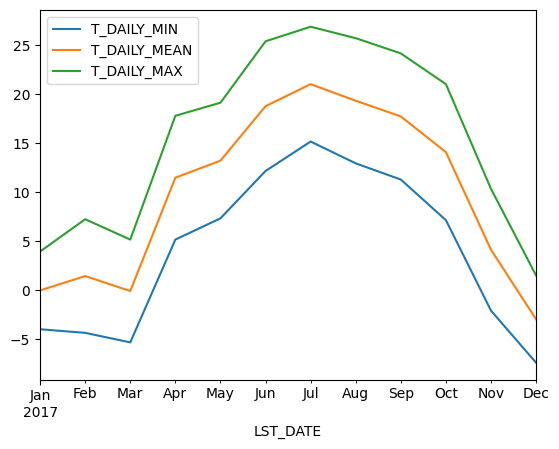

In [64]:
df_mm = df.select_dtypes(include='number').resample('MS').mean()
df_mm[['T_DAILY_MIN', 'T_DAILY_MEAN', 'T_DAILY_MAX']].plot()

:::{admonition} Try it
:class: tip
Use `df.resample('YE').mean()` to get yearly means and plot `T_DAILY_MAX` against the resulting index as a line chart. Then do the same with `'10D'` (10-day bins) — the lower-frequency series should look smoother.
:::

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


Text(0.5, 1.0, 'T_DAILY_MAX resampled')

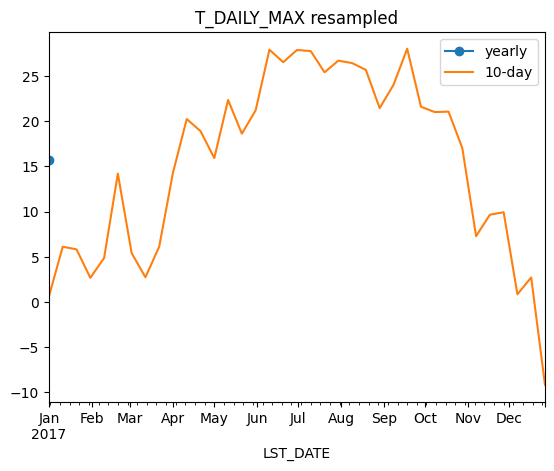

In [65]:
# Try it — my attempt
df.resample('YE').mean(numeric_only=True)['T_DAILY_MAX'].plot(marker='o', label='yearly')
df.resample('10D').mean(numeric_only=True)['T_DAILY_MAX'].plot(label='10-day')
plt.legend(); plt.title('T_DAILY_MAX resampled')

## Recap

You've now met the two core pandas objects and the everyday ways to work with them:

- **Series and DataFrames** — labelled 1-D and 2-D data, with `.info()` and `.describe()` for a quick look.
- **Indexing** — `.loc` (by label), `.iloc` (by position), and boolean masks to filter rows by a condition.
- **Building and combining** — adding computed columns, and joining a Series or DataFrame on a shared index.
- **Reading real data** — `read_csv` with `sep`, `na_values`, and `parse_dates`, then setting a column as the index.
- **Time series** — a `DatetimeIndex`, slicing by date, plotting straight from a DataFrame, and a first taste of `resample`.

Next we go deeper into grouping operations — `groupby`, `resample`, and `rolling` — in [Pandas: Groupby](./pandas_groupby.ipynb).